In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Your value-added results (6-digit, stream-specific)
venky_df = pd.read_csv("venky_va_501502_bpc.csv")

# Saee’s value-added results (5-digit college-level)
saee_df = pd.read_stata("saee_va_30016base.dta")

# Master mapping dataset
master_df = pd.read_stata("1.5kcolleges_student&collegedetails_v2_limitedvars.dta")


In [3]:
mapping = (
    master_df[["allotted_JC_code", "coll_code_went"]]
    .dropna()
    .drop_duplicates()
)

# normalize formats
mapping["allotted_JC_code"] = mapping["allotted_JC_code"].astype(str).str.lower().str.strip()
mapping["coll_code_went"] = mapping["coll_code_went"].astype(str).str.strip()

print("Mapping rows:", mapping.shape[0])
mapping.head()


Mapping rows: 1846


,allotted_JC_code,coll_code_went
0,,54018.0
1,,56234.0
2,,56024.0
3,508402_bpc,50018.0
4,511901_mpc,42008.0


In [4]:
venky_df = venky_df.rename(columns={
    "college_code": "allotted_JC_code",
    "value_added": "venky_VA"
})

venky_df["allotted_JC_code"] = venky_df["allotted_JC_code"].astype(str).str.lower().str.strip()

venky_df = venky_df[["allotted_JC_code", "venky_VA"]].dropna()

print("Your VA rows:", venky_df.shape[0])
venky_df.head()


Your VA rows: 192


,allotted_JC_code,venky_VA
0,501601_mpc,1.190646
1,501602_bpc,0.840444
2,501801_mpc,0.504418
3,501802_bpc,0.894981
4,501903_mec,-1.930657


In [5]:
saee_df = saee_df.rename(columns={
    "coll_code": "coll_code_went",
    "VA_5": "saee_VA"
})

saee_df["coll_code_went"] = saee_df["coll_code_went"].astype(str).str.strip()

saee_df = saee_df[["coll_code_went", "saee_VA"]].dropna()

print("Saee VA rows:", saee_df.shape[0])
saee_df.head()


Saee VA rows: 1722


,coll_code_went,saee_VA
0,30001.0,-29.354523
1,30002.0,-16.169211
2,30003.0,-8.752134
3,30004.0,-8.473180
4,30005.0,-10.023411


In [6]:
# Step 1: your VA (6-digit) → mapping
merged = venky_df.merge(
    mapping,
    on="allotted_JC_code",
    how="left"
)

# Step 2: bring in Saee’s VA (5-digit)
merged = merged.merge(
    saee_df,
    on="coll_code_went",
    how="left"
)

print("Final merged rows:", merged.shape[0])
merged.head()


Final merged rows: 192


,allotted_JC_code,venky_VA,coll_code_went,saee_VA
0,501601_mpc,1.190646,33014.0,-7.202116
1,501602_bpc,0.840444,33014.0,-7.202116
2,501801_mpc,0.504418,31016.0,-3.135446
3,501802_bpc,0.894981,31016.0,-3.135446
4,501903_mec,-1.930657,33013.0,-5.981785


In [7]:
print("Streams with Saee match:",
      merged["saee_VA"].notna().sum())

print("Streams without Saee match:",
      merged["saee_VA"].isna().sum())


Streams with Saee match: 192
Streams without Saee match: 0


In [8]:
plot_df = merged.dropna(subset=["venky_VA", "saee_VA"])
print("Plotting rows:", plot_df.shape[0])


Plotting rows: 192


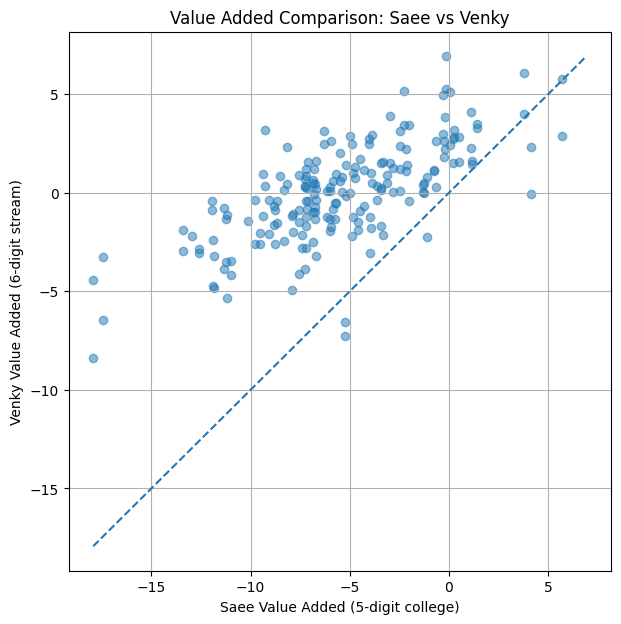

In [9]:
plt.figure(figsize=(7, 7))

plt.scatter(
    plot_df["saee_VA"],
    plot_df["venky_VA"],
    alpha=0.5
)

# 45-degree line
lims = [
    min(plot_df["saee_VA"].min(), plot_df["venky_VA"].min()),
    max(plot_df["saee_VA"].max(), plot_df["venky_VA"].max())
]
plt.plot(lims, lims, linestyle="--")

plt.xlabel("Saee Value Added (5-digit college)")
plt.ylabel("Venky Value Added (6-digit stream)")
plt.title("Value Added Comparison: Saee vs Venky")

plt.grid(True)
plt.show()


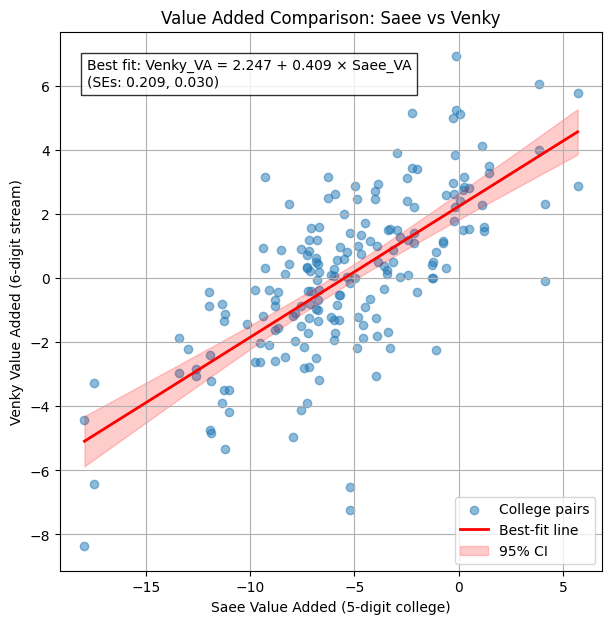

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# DATA
# -----------------------------
x = plot_df["saee_VA"].astype(float)
y = plot_df["venky_VA"].astype(float)

# Drop missing values
mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]

# -----------------------------
# OLS REGRESSION
# y = a + b x
# -----------------------------
X = sm.add_constant(x)
ols_model = sm.OLS(y, X).fit()

a, b = ols_model.params
a_se, b_se = ols_model.bse

# -----------------------------
# PREDICTION GRID + CI
# -----------------------------
x_grid = np.linspace(x.min(), x.max(), 200)
X_grid = sm.add_constant(x_grid)

pred = ols_model.get_prediction(X_grid)
pred_mean = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7, 7))

# Scatter
plt.scatter(
    x,
    y,
    alpha=0.5,
    label="College pairs"
)

# Best-fit line
plt.plot(
    x_grid,
    pred_mean,
    color="red",
    linewidth=2,
    label="Best-fit line"
)

# Confidence interval
plt.fill_between(
    x_grid,
    ci_low,
    ci_high,
    color="red",
    alpha=0.2,
    label="95% CI"
)

# Labels
plt.xlabel("Saee Value Added (5-digit college)")
plt.ylabel("Venky Value Added (6-digit stream)")
plt.title("Value Added Comparison: Saee vs Venky")

# Equation annotation
eqn_text = (
    f"Best fit: Venky_VA = {a:.3f} "
    f"+ {b:.3f} × Saee_VA\n"
    f"(SEs: {a_se:.3f}, {b_se:.3f})"
)

plt.text(
    0.05,
    0.95,
    eqn_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid(True)
plt.show()


In [11]:
corr = plot_df["saee_VA"].corr(plot_df["venky_VA"])
print("Correlation between value-added estimates:", round(corr, 3))


Correlation between value-added estimates: 0.702


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
pair_bin_long = pd.read_csv("pair_bin_long.csv")

students = pd.read_csv("final_rudimentary_grouping.csv")[
    ["candidate_id_68k", "englishmarks_12", "allotted_JC_code"]
]

va_df = pd.read_csv("venky_va_501502_bpc.csv")


C:\Users\lenovo\AppData\Local\Temp\ipykernel_35696\3399673781.py:3: DtypeWarning: Columns (21,22,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  students = pd.read_csv("final_rudimentary_grouping.csv")[


In [14]:
pair_bin_long["student_id"] = pair_bin_long["student_id"].astype(str)
students["candidate_id_68k"] = students["candidate_id_68k"].astype(str)

students["allotted_JC_code"] = (
    students["allotted_JC_code"]
    .astype(str).str.lower().str.strip()
)

va_df["college_code"] = (
    va_df["college_code"]
    .astype(str).str.lower().str.strip()
)


In [15]:
df = pair_bin_long.merge(
    students,
    left_on="student_id",
    right_on="candidate_id_68k",
    how="left"
)

df = df.dropna(subset=["englishmarks_12", "allotted_JC_code"])


In [16]:
def extract_colleges(pair_id):
    core = pair_id.replace(".1", "")
    A, B = core.split("x")
    return A.lower(), B.lower()

df[["college_A", "college_B"]] = df["pair_id"].apply(
    lambda x: pd.Series(extract_colleges(x))
)


In [17]:
df = df[
    (df["allotted_JC_code"] == df["college_A"]) |
    (df["allotted_JC_code"] == df["college_B"])
]


In [18]:
df["englishmarks_12"] = pd.to_numeric(df["englishmarks_12"], errors="coerce")
bin_means = (
    df
    .groupby(["pair_id", "bin_id", "allotted_JC_code"])["englishmarks_12"]
    .mean()
    .reset_index()
)


In [19]:
# -----------------------------
# STEP 6: Δ MARKS PER PAIR–BIN
# -----------------------------

# 1. Pivot to wide format
bin_wide = (
    bin_means
    .pivot(
        index=["pair_id", "bin_id"],
        columns="allotted_JC_code",
        values="englishmarks_12"
    )
    .reset_index()
)

# 2. Extract college A and B from pair_id (AxB.1)
def extract_colleges(pair_id):
    A, rest = pair_id.split("x")
    B = rest.split(".")[0]
    return A, B

bin_wide[["college_A", "college_B"]] = (
    bin_wide["pair_id"]
    .apply(lambda x: pd.Series(extract_colleges(x)))
)

# 3. Keep only rows where both colleges are present
bin_wide = bin_wide.dropna(
    subset=["college_A", "college_B"]
)

# 4. Compute Δ marks = mean(A) − mean(B)
bin_wide["delta_marks"] = bin_wide.apply(
    lambda r: r[r["college_A"]] - r[r["college_B"]],
    axis=1
)

delta_marks_df = bin_wide[
    ["pair_id", "bin_id", "college_A", "college_B", "delta_marks"]
]

print("Δ-marks rows:", delta_marks_df.shape[0])
display(delta_marks_df.head())


Δ-marks rows: 5140


allotted_JC_code,pair_id,bin_id,college_A,college_B,delta_marks
0,501502_bpcx501601_mpc.1,501502_bpcx501601_mpc.1__marks_20_24,501502_bpc,501601_mpc,-3.000000
1,501502_bpcx501601_mpc.1,501502_bpcx501601_mpc.1__marks_25_29,501502_bpc,501601_mpc,-0.833333
2,501502_bpcx501601_mpc.1,501502_bpcx501601_mpc.1__marks_35_39,501502_bpc,501601_mpc,-2.444444
3,501502_bpcx501602_bpc.1,501502_bpcx501602_bpc.1__marks_15_19,501502_bpc,501602_bpc,2.600000
4,501502_bpcx501602_bpc.1,501502_bpcx501602_bpc.1__marks_40_44,501502_bpc,501602_bpc,-0.076923


In [20]:
va = pd.read_csv("venky_va_501502_bpc.csv")

va["college_code"] = va["college_code"].astype(str)


In [21]:
# Merge VA for college A
delta_marks_df = delta_marks_df.merge(
    va.rename(columns={"college_code": "college_A", "value_added": "va_A"}),
    on="college_A",
    how="left"
)

# Merge VA for college B
delta_marks_df = delta_marks_df.merge(
    va.rename(columns={"college_code": "college_B", "value_added": "va_B"}),
    on="college_B",
    how="left"
)

# Compute Δ VA
delta_marks_df["delta_va"] = (
    delta_marks_df["va_A"] - delta_marks_df["va_B"]
)

# Drop incomplete cases
plot_df = delta_marks_df.dropna(
    subset=["delta_marks", "delta_va"]
)

print("Final plotting rows:", plot_df.shape[0])
display(plot_df.head())


Final plotting rows: 5059


,pair_id,bin_id,college_A,college_B,delta_marks,va_A,std_error_x,p_value_x,va_B,std_error_y,p_value_y,delta_va
44,501601_mpcx501602_bpc.1,501601_mpcx501602_bpc.1__marks_15_19,501601_mpc,501602_bpc,-31.000000,1.190646,0.590301,0.043694,0.840444,0.416157,0.043432,0.350202
45,501601_mpcx501602_bpc.1,501601_mpcx501602_bpc.1__marks_20_24,501601_mpc,501602_bpc,10.000000,1.190646,0.590301,0.043694,0.840444,0.416157,0.043432,0.350202
46,501601_mpcx501602_bpc.1,501601_mpcx501602_bpc.1__marks_40_44,501601_mpc,501602_bpc,0.666667,1.190646,0.590301,0.043694,0.840444,0.416157,0.043432,0.350202
47,501601_mpcx501801_mpc.1,501601_mpcx501801_mpc.1__marks_25_29,501601_mpc,501801_mpc,-4.500000,1.190646,0.590301,0.043694,0.504418,0.421540,0.231459,0.686228
48,501601_mpcx501801_mpc.1,501601_mpcx501801_mpc.1__marks_35_39,501601_mpc,501801_mpc,0.166667,1.190646,0.590301,0.043694,0.504418,0.421540,0.231459,0.686228


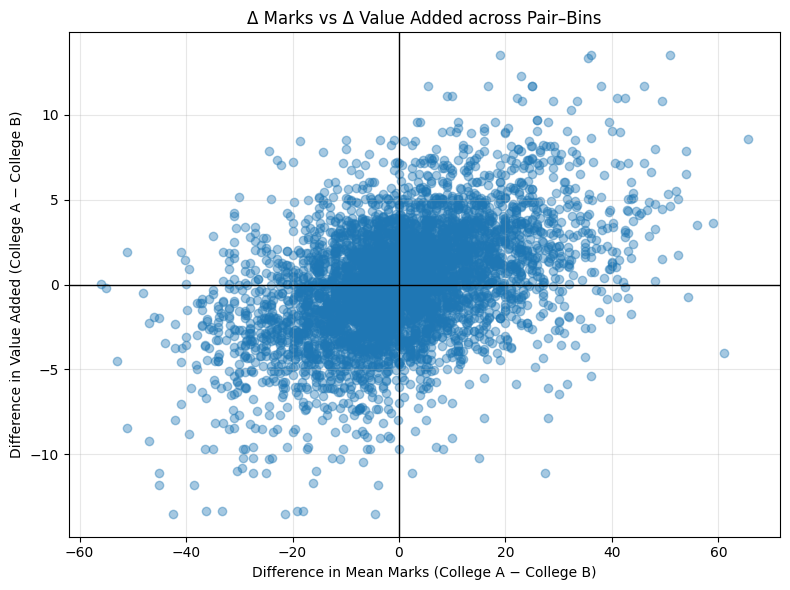

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df["delta_marks"],
    plot_df["delta_va"],
    alpha=0.4
)

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Difference in Mean Marks (College A − College B)")
plt.ylabel("Difference in Value Added (College A − College B)")
plt.title("Δ Marks vs Δ Value Added across Pair–Bins")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
pair_level_marks = (
    delta_marks_df
    .groupby(["pair_id", "college_A", "college_B"])["delta_marks"]
    .mean()
    .reset_index()
    .rename(columns={"delta_marks": "avg_delta_marks"})
)

print("College-pair rows:", pair_level_marks.shape[0])
display(pair_level_marks.head())


College-pair rows: 2075


,pair_id,college_A,college_B,avg_delta_marks
0,501502_bpcx501601_mpc.1,501502_bpc,501601_mpc,-2.092593
1,501502_bpcx501602_bpc.1,501502_bpc,501602_bpc,1.132692
2,501502_bpcx501801_mpc.1,501502_bpc,501801_mpc,2.729167
3,501502_bpcx501802_bpc.1,501502_bpc,501802_bpc,2.398810
4,501502_bpcx501903_mec.1,501502_bpc,501903_mec,7.981944


In [24]:
# merge VA for college A
pair_level = pair_level_marks.merge(
    va.rename(columns={
        "college_code": "college_A",
        "value_added": "va_A"
    }),
    on="college_A",
    how="left"
)

# merge VA for college B
pair_level = pair_level.merge(
    va_df.rename(columns={
        "college_code": "college_B",
        "value_added": "va_B"
    }),
    on="college_B",
    how="left"
)

# compute Δ VA
pair_level["delta_va"] = pair_level["va_A"] - pair_level["va_B"]

display(pair_level.head())


,pair_id,college_A,college_B,avg_delta_marks,va_A,std_error_x,p_value_x,va_B,std_error_y,p_value_y,delta_va
0,501502_bpcx501601_mpc.1,501502_bpc,501601_mpc,-2.092593,NaN,NaN,NaN,1.190646,0.590301,0.043694,NaN
1,501502_bpcx501602_bpc.1,501502_bpc,501602_bpc,1.132692,NaN,NaN,NaN,0.840444,0.416157,0.043432,NaN
2,501502_bpcx501801_mpc.1,501502_bpc,501801_mpc,2.729167,NaN,NaN,NaN,0.504418,0.421540,0.231459,NaN
3,501502_bpcx501802_bpc.1,501502_bpc,501802_bpc,2.398810,NaN,NaN,NaN,0.894981,0.410170,0.029111,NaN
4,501502_bpcx501903_mec.1,501502_bpc,501903_mec,7.981944,NaN,NaN,NaN,-1.930657,0.684271,0.004780,NaN


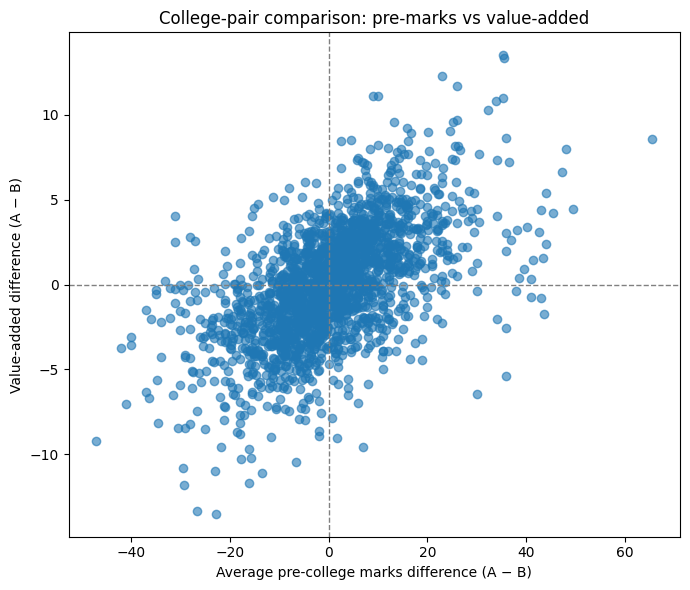

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    pair_level["avg_delta_marks"],
    pair_level["delta_va"],
    alpha=0.6
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Average pre-college marks difference (A − B)")
plt.ylabel("Value-added difference (A − B)")
plt.title("College-pair comparison: pre-marks vs value-added")

plt.tight_layout()
plt.show()


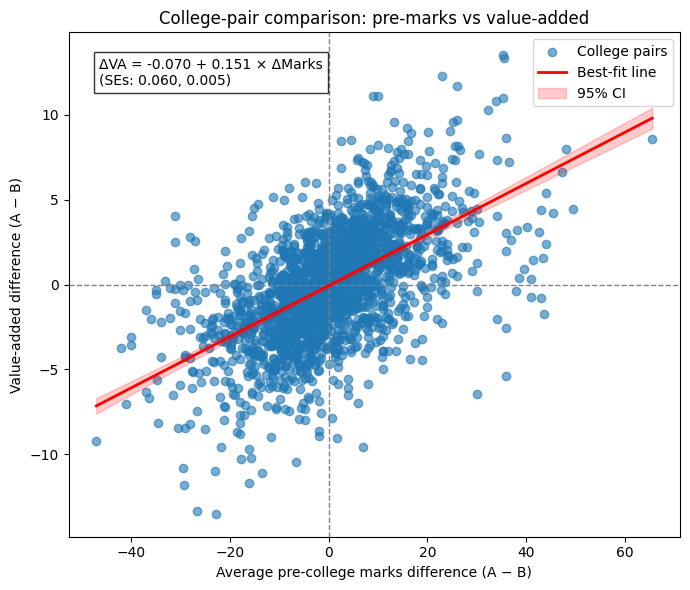

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# DATA
# -----------------------------
x = pair_level["avg_delta_marks"].astype(float)
y = pair_level["delta_va"].astype(float)

# Drop missing
mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]

# -----------------------------
# OLS REGRESSION
# y = a + b x
# -----------------------------
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

a, b = model.params
a_se, b_se = model.bse

# -----------------------------
# PREDICTIONS + CI
# -----------------------------
x_grid = np.linspace(x.min(), x.max(), 200)
X_grid = sm.add_constant(x_grid)

pred = model.get_prediction(X_grid)
y_hat = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7, 6))

# Scatter
plt.scatter(
    x,
    y,
    alpha=0.6,
    label="College pairs"
)

# Zero reference lines
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

# Best-fit line
plt.plot(
    x_grid,
    y_hat,
    color="red",
    linewidth=2,
    label="Best-fit line"
)

# Confidence interval
plt.fill_between(
    x_grid,
    ci_low,
    ci_high,
    color="red",
    alpha=0.2,
    label="95% CI"
)

# Labels
plt.xlabel("Average pre-college marks difference (A − B)")
plt.ylabel("Value-added difference (A − B)")
plt.title("College-pair comparison: pre-marks vs value-added")

# Equation annotation
eqn = (
    f"ΔVA = {a:.3f} + {b:.3f} × ΔMarks\n"
    f"(SEs: {a_se:.3f}, {b_se:.3f})"
)

plt.text(
    0.05,
    0.95,
    eqn,
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.tight_layout()
plt.show()
